# File for analyzing the data and finding thresholds

Description: We will first parse all the files to map each clip summary with its respective ground truth label, then we will parse all of the datapoints and graph them for each of the metrics of interest. Lastly, we will gather some heuristics e.g. mean, median, or min to use as a threshold for comparing model-agnostic action classification with few-shot prompting. 

### 1. Create a separate file matching all clip ground truth actions to their summary 

In [1]:
#!/usr/bin/env python3
"""
Batch match SLAM summary files with corresponding label files.

Example:
    henry_slam_clip_summaries.json
    henry_labels.csv
"""

import json
import pandas as pd
from pathlib import Path

# ==========================
# CONFIG
# ==========================
SLAM_FOLDER = Path("/Users/jayden/Qwen2.5-VL/data/summaries")
LABEL_FOLDER = Path("/Users/jayden/Qwen2.5-VL/data/labels")
OUTPUT_FOLDER = Path("merged_output")

OUTPUT_FOLDER.mkdir(exist_ok=True)


In [2]:
# ==========================
# HELPERS
# ==========================
def load_and_flatten_slam(json_path):
    with open(json_path, "r") as f:
        slam_data = json.load(f)

    slam_df = pd.DataFrame(slam_data)

    features_df = pd.json_normalize(slam_df["slam_features"])

    slam_df = pd.concat(
        [
            slam_df[
                [
                    "clip_index",
                    "clip_start_utc_ns",
                    "clip_end_utc_ns",
                    "slam_text_summary",
                ]
            ],
            features_df,
        ],
        axis=1,
    )

    return slam_df


def load_and_format_labels(csv_path):
    gt_df = pd.read_csv(csv_path)

    # Convert: video_clips_clip0003 → clip_0003
    gt_df["clip_index"] = (
        gt_df["video_id"]
        .str.extract(r"clip(\d+)")[0]
        .astype(int)
        .apply(lambda x: f"clip_{x:04d}")
    )

    return gt_df[["clip_index", "action_label"]]


In [3]:
# ==========================
# MAIN LOOP
# ==========================
for slam_file in SLAM_FOLDER.glob("*_slam_clip_summaries.json"):
    # Extract subject name
    subject_name = slam_file.name.replace("_slam_clip_summaries.json", "")

    label_file = LABEL_FOLDER / f"{subject_name}_labels.csv"

    if not label_file.exists():
        print(f"⚠️ No matching label file for {slam_file.name}")
        continue

    print(f"\nProcessing subject: {subject_name}")

    slam_df = load_and_flatten_slam(slam_file)
    gt_df = load_and_format_labels(label_file)

    merged_df = slam_df.merge(gt_df, on="clip_index", how="inner")

    print(f"  Total SLAM clips: {len(slam_df)}")
    print(f"  Matched clips: {len(merged_df)}")

    output_path = OUTPUT_FOLDER / f"{subject_name}_merged.json"
    merged_df.to_json(output_path, orient="records", indent=2)

print("\n✅ Batch processing complete.")


Processing subject: Jayden
  Total SLAM clips: 30
  Matched clips: 30

Processing subject: Henry
  Total SLAM clips: 38
  Matched clips: 38

Processing subject: Jayden5
  Total SLAM clips: 121
  Matched clips: 121

Processing subject: Jayden3
  Total SLAM clips: 123
  Matched clips: 123

Processing subject: Jayden2
  Total SLAM clips: 67
  Matched clips: 67

✅ Batch processing complete.


### 2. Make mega dataset by combining all individual files in merged_output

In [4]:
#!/usr/bin/env python3
"""
Combine all *_merged.json files into one master dataset
with globally continuous clip_index numbering.
"""

import pandas as pd
from pathlib import Path

# ==========================
# CONFIG
# ==========================
MERGED_FOLDER = Path("merged_output")
OUTPUT_FILE = "master_dataset.json"

# ==========================
# LOAD & CONCAT
# ==========================
all_dfs = []

for file in sorted(MERGED_FOLDER.glob("*_merged.json")):
    print(f"Loading {file.name}")

    df = pd.read_json(file)

    subject_name = file.stem.replace("_merged", "")
    df["subject"] = subject_name

    all_dfs.append(df)

if not all_dfs:
    raise ValueError("No merged files found.")

master_df = pd.concat(all_dfs, ignore_index=True)

# ==========================
# RESET CLIP NUMBERING GLOBALLY
# ==========================
master_df = master_df.reset_index(drop=True)

# Create new continuous clip index
master_df["clip_index"] = master_df.index.map(lambda x: f"clip_{x:04d}")

print(f"\nTotal clips combined: {len(master_df)}")
print("Clip indices reassigned globally.")

# ==========================
# SAVE
# ==========================
master_df.to_json(OUTPUT_FILE, orient="records", indent=2)

print(f"✅ Saved master dataset to {OUTPUT_FILE}")

Loading Henry_merged.json
Loading Jayden2_merged.json
Loading Jayden3_merged.json
Loading Jayden5_merged.json
Loading Jayden_merged.json

Total clips combined: 379
Clip indices reassigned globally.
✅ Saved master dataset to master_dataset.json


In [5]:
!pip install matplotlib


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Horizontal Displacement Statistics (m) per Action:

go upstair   | mean: 0.776 | median: 0.727 | min: 0.291 | 25%: 0.606 | 75%: 0.925 | max: 1.402
walking      | mean: 1.474 | median: 1.471 | min: 0.212 | 25%: 1.022 | 75%: 1.826 | max: 2.811
standing     | mean: 0.348 | median: 0.290 | min: 0.031 | 25%: 0.166 | 75%: 0.491 | max: 1.028
go downstair | mean: 0.748 | median: 0.693 | min: 0.127 | 25%: 0.555 | 75%: 0.950 | max: 1.411
sitting      | mean: 0.205 | median: 0.115 | min: 0.000 | 25%: 0.038 | 75%: 0.290 | max: 1.016


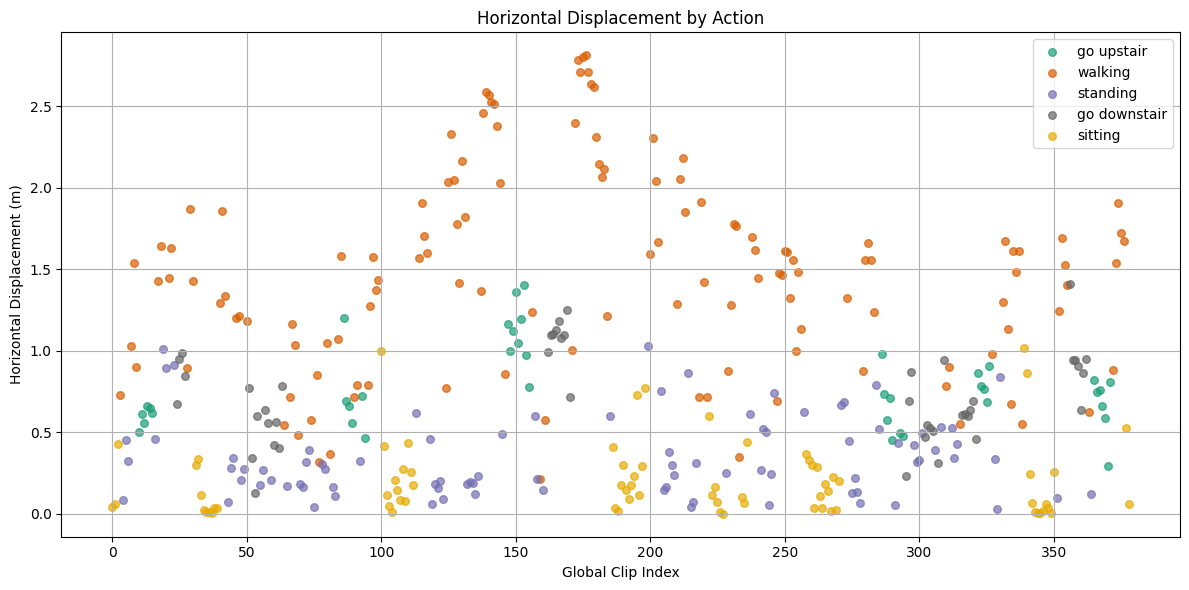

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# LOAD MASTER DATASET
# ==========================
df = pd.read_json("master_dataset.json")

# Ensure the horizontal_displacement_m column exists
if "horizontal_displacement_m" not in df.columns:
    raise ValueError("Column horizontal_displacement_m not found in dataset.")

# ==========================
# COLOR MAP
# ==========================
color_map = {
    "go upstair": "#1b9e77",
    "walking": "#d95f02",
    "standing": "#7570b3",
    "go downstair": "#666666",
    "sitting": "#e6ab02",
}

# ==========================
# COMPUTE STATISTICS PER ACTION
# ==========================
print("Horizontal Displacement Statistics (m) per Action:\n")
stats = []

for action in color_map.keys():
    subset = df[df["action_label"] == action]
    if not subset.empty:
        mean_val = subset["horizontal_displacement_m"].mean()
        median_val = subset["horizontal_displacement_m"].median()
        min_val = subset["horizontal_displacement_m"].min()
        q25 = subset["horizontal_displacement_m"].quantile(0.25)
        q75 = subset["horizontal_displacement_m"].quantile(0.75)
        max_val = subset["horizontal_displacement_m"].max()

        stats.append((action, mean_val, median_val, min_val, q25, q75, max_val))

        print(
            f"{action:12s} | mean: {mean_val:.3f} | median: {median_val:.3f} | "
            f"min: {min_val:.3f} | 25%: {q25:.3f} | 75%: {q75:.3f} | max: {max_val:.3f}"
        )

# ==========================
# PLOT
# ==========================
plt.figure(figsize=(12, 6))

for action, color in color_map.items():
    subset = df[df["action_label"] == action]
    if not subset.empty:
        plt.scatter(
            subset.index,  # global clip index
            subset["horizontal_displacement_m"],
            color=color,
            label=action,
            s=30,  # marker size
            alpha=0.7,
        )

plt.xlabel("Global Clip Index")
plt.ylabel("Horizontal Displacement (m)")
plt.title("Horizontal Displacement by Action")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Vertical Displacement Statistics (m) per Action:

go upstair   | mean: 0.428 | median: 0.476 | min: -0.049 | 25%: 0.355 | 75%: 0.576 | max: 0.721
walking      | mean: 0.009 | median: -0.002 | min: -0.705 | 25%: -0.023 | 75%: 0.027 | max: 0.664
standing     | mean: 0.012 | median: -0.005 | min: -0.541 | 25%: -0.054 | 75%: 0.036 | max: 0.980
go downstair | mean: -0.413 | median: -0.460 | min: -0.921 | 25%: -0.516 | 75%: -0.256 | max: 0.101
sitting      | mean: -0.017 | median: -0.008 | min: -0.377 | 25%: -0.040 | 75%: 0.016 | max: 0.428


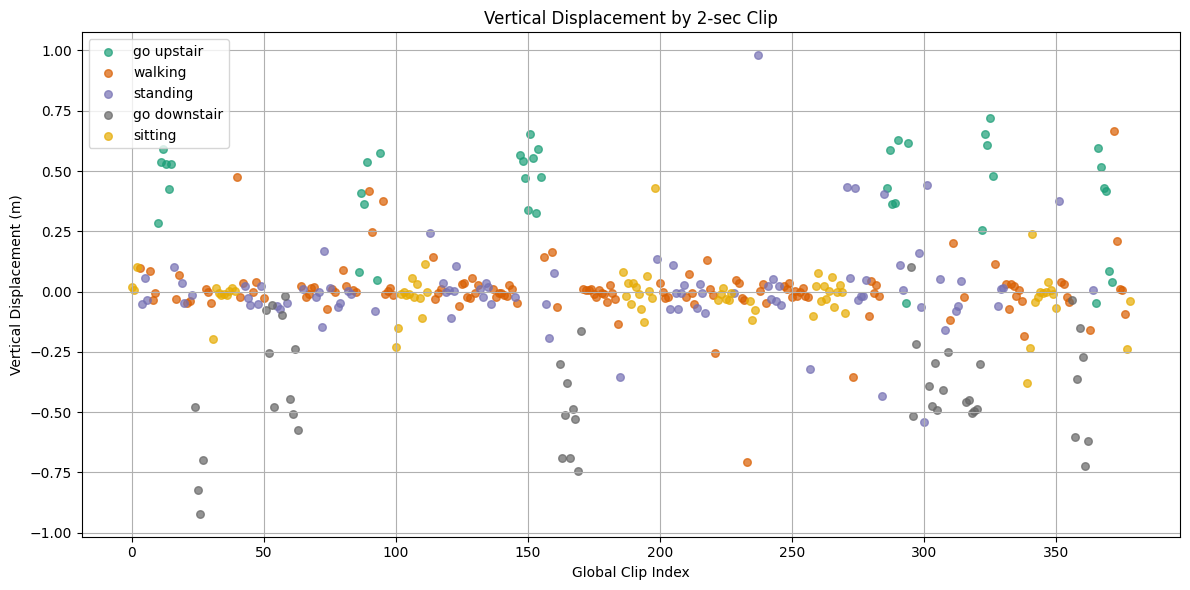

In [7]:
# ==========================
# LOAD MASTER DATASET
# ==========================
df = pd.read_json("master_dataset.json")

# Ensure the vertical_displacement_m column exists
if "vertical_displacement_m" not in df.columns:
    raise ValueError("Column vertical_displacement_m not found in dataset.")

# ==========================
# COLOR MAP
# ==========================
color_map = {
    "go upstair": "#1b9e77",
    "walking": "#d95f02",
    "standing": "#7570b3",
    "go downstair": "#666666",
    "sitting": "#e6ab02",
}

# ==========================
# COMPUTE STATISTICS PER ACTION
# ==========================
print("Vertical Displacement Statistics (m) per Action:\n")
stats = []

for action in color_map.keys():
    subset = df[df["action_label"] == action]
    if not subset.empty:
        mean_val = subset["vertical_displacement_m"].mean()
        median_val = subset["vertical_displacement_m"].median()
        min_val = subset["vertical_displacement_m"].min()
        q25 = subset["vertical_displacement_m"].quantile(0.25)
        q75 = subset["vertical_displacement_m"].quantile(0.75)
        max_val = subset["vertical_displacement_m"].max()

        stats.append((action, mean_val, median_val, min_val, q25, q75, max_val))

        print(
            f"{action:12s} | mean: {mean_val:.3f} | median: {median_val:.3f} | "
            f"min: {min_val:.3f} | 25%: {q25:.3f} | 75%: {q75:.3f} | max: {max_val:.3f}"
        )

# ==========================
# PLOT
# ==========================
plt.figure(figsize=(12, 6))

for action, color in color_map.items():
    subset = df[df["action_label"] == action]
    if not subset.empty:
        plt.scatter(
            subset.index,  # global clip index
            subset["vertical_displacement_m"],
            color=color,
            label=action,
            s=30,  # marker size
            alpha=0.7,
        )

plt.xlabel("Global Clip Index")
plt.ylabel("Vertical Displacement (m)")
plt.title("Vertical Displacement by 2-sec Clip")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

mean_angular_speed Statistics (m/s) per Action:

go upstair   | mean: 0.351 | median: 0.323 | min: 0.140 | 25%: 0.227 | 75%: 0.474 | max: 0.654
walking      | mean: 0.352 | median: 0.314 | min: 0.135 | 25%: 0.217 | 75%: 0.435 | max: 0.962
standing     | mean: 0.515 | median: 0.489 | min: 0.101 | 25%: 0.294 | 75%: 0.671 | max: 1.619
go downstair | mean: 0.330 | median: 0.287 | min: 0.152 | 25%: 0.208 | 75%: 0.428 | max: 0.744
sitting      | mean: 0.217 | median: 0.179 | min: 0.014 | 25%: 0.077 | 75%: 0.290 | max: 0.830


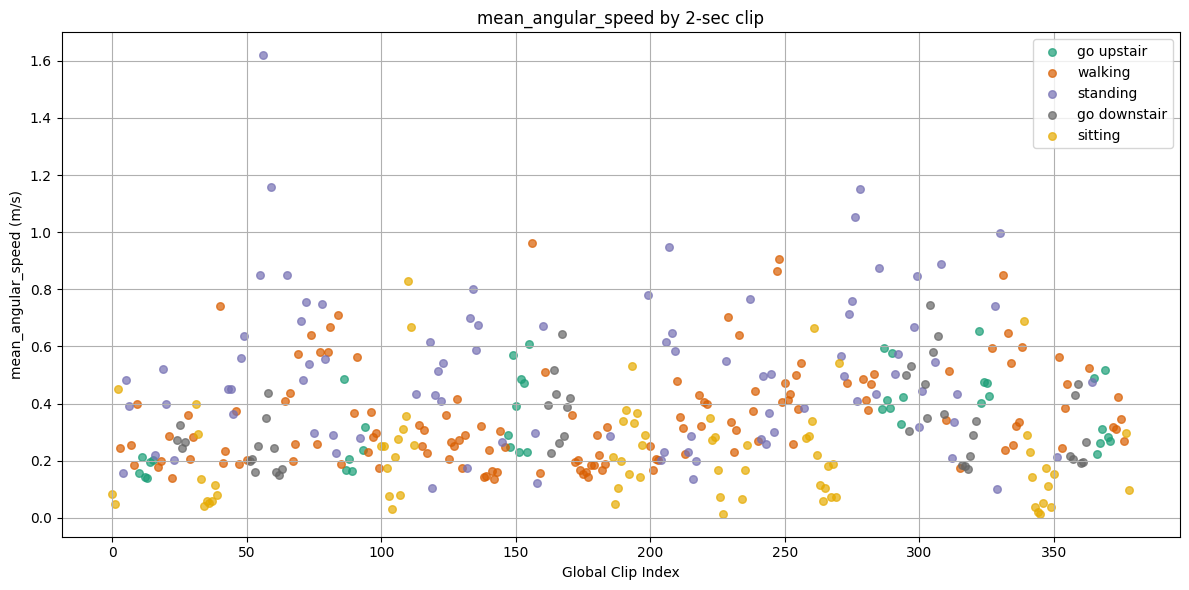

In [8]:
# ==========================
# LOAD MASTER DATASET
# ==========================
df = pd.read_json("master_dataset.json")

# Ensure the mean_angular_speed column exists
if "mean_angular_speed" not in df.columns:
    raise ValueError("Column mean_angular_speed not found in dataset.")

# ==========================
# COLOR MAP
# ==========================
color_map = {
    "go upstair": "#1b9e77",
    "walking": "#d95f02",
    "standing": "#7570b3",
    "go downstair": "#666666",
    "sitting": "#e6ab02",
}

# ==========================
# COMPUTE STATISTICS PER ACTION
# ==========================
print("mean_angular_speed Statistics (m/s) per Action:\n")
stats = []

for action in color_map.keys():
    subset = df[df["action_label"] == action]
    if not subset.empty:
        mean_val = subset["mean_angular_speed"].mean()
        median_val = subset["mean_angular_speed"].median()
        min_val = subset["mean_angular_speed"].min()
        q25 = subset["mean_angular_speed"].quantile(0.25)
        q75 = subset["mean_angular_speed"].quantile(0.75)
        max_val = subset["mean_angular_speed"].max()

        stats.append((action, mean_val, median_val, min_val, q25, q75, max_val))

        print(
            f"{action:12s} | mean: {mean_val:.3f} | median: {median_val:.3f} | "
            f"min: {min_val:.3f} | 25%: {q25:.3f} | 75%: {q75:.3f} | max: {max_val:.3f}"
        )

# ==========================
# PLOT
# ==========================
plt.figure(figsize=(12, 6))

for action, color in color_map.items():
    subset = df[df["action_label"] == action]
    if not subset.empty:
        plt.scatter(
            subset.index,  # global clip index
            subset["mean_angular_speed"],
            color=color,
            label=action,
            s=30,  # marker size
            alpha=0.7,
        )

plt.xlabel("Global Clip Index")
plt.ylabel("mean_angular_speed (m/s)")
plt.title("mean_angular_speed by 2-sec clip")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

mean_speed_mps Statistics (m/s) per Action:

go upstair   | mean: 0.557 | median: 0.552 | min: 0.177 | 25%: 0.469 | 75%: 0.629 | max: 0.835
walking      | mean: 0.808 | median: 0.816 | min: 0.169 | 25%: 0.599 | 75%: 0.945 | max: 1.449
standing     | mean: 0.304 | median: 0.270 | min: 0.052 | 25%: 0.167 | 75%: 0.412 | max: 0.879
go downstair | mean: 0.533 | median: 0.499 | min: 0.144 | 25%: 0.442 | 75%: 0.649 | max: 0.775
sitting      | mean: 0.166 | median: 0.110 | min: 0.005 | 25%: 0.041 | 75%: 0.276 | max: 0.656


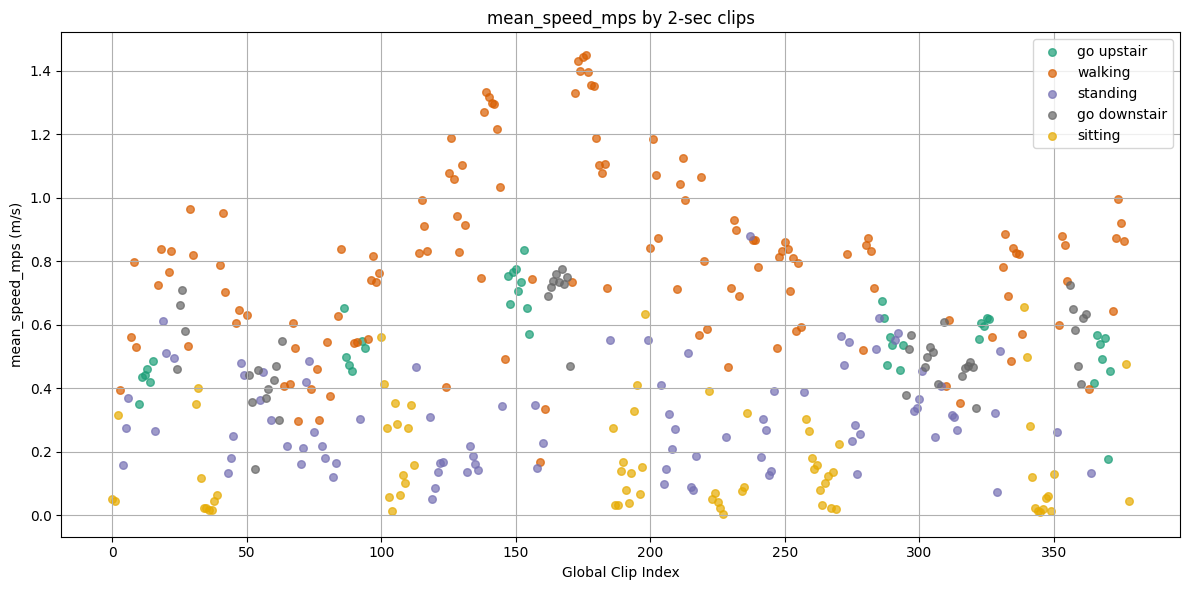

In [9]:
# ==========================
# LOAD MASTER DATASET
# ==========================
df = pd.read_json("master_dataset.json")

# Ensure the mean_speed_mps column exists
if "mean_speed_mps" not in df.columns:
    raise ValueError("Column mean_speed_mps not found in dataset.")

# ==========================
# COLOR MAP
# ==========================
color_map = {
    "go upstair": "#1b9e77",
    "walking": "#d95f02",
    "standing": "#7570b3",
    "go downstair": "#666666",
    "sitting": "#e6ab02",
}

# ==========================
# COMPUTE STATISTICS PER ACTION
# ==========================
print("mean_speed_mps Statistics (m/s) per Action:\n")
stats = []

for action in color_map.keys():
    subset = df[df["action_label"] == action]
    if not subset.empty:
        mean_val = subset["mean_speed_mps"].mean()
        median_val = subset["mean_speed_mps"].median()
        min_val = subset["mean_speed_mps"].min()
        q25 = subset["mean_speed_mps"].quantile(0.25)
        q75 = subset["mean_speed_mps"].quantile(0.75)
        max_val = subset["mean_speed_mps"].max()

        stats.append((action, mean_val, median_val, min_val, q25, q75, max_val))

        print(
            f"{action:12s} | mean: {mean_val:.3f} | median: {median_val:.3f} | "
            f"min: {min_val:.3f} | 25%: {q25:.3f} | 75%: {q75:.3f} | max: {max_val:.3f}"
        )

# ==========================
# PLOT
# ==========================
plt.figure(figsize=(12, 6))

for action, color in color_map.items():
    subset = df[df["action_label"] == action]
    if not subset.empty:
        plt.scatter(
            subset.index,  # global clip index
            subset["mean_speed_mps"],
            color=color,
            label=action,
            s=30,  # marker size
            alpha=0.7,
        )

plt.xlabel("Global Clip Index")
plt.ylabel("mean_speed_mps (m/s)")
plt.title("mean_speed_mps by 2-sec clips")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Prediction: Using only deterministic if statements and the statistics compiled, check the accuracy of a model-agnostic prediction

In [10]:
#!/usr/bin/env python3

import json
from pathlib import Path
from collections import defaultdict

# ==========================
# CONFIG
# ==========================
INPUT_FOLDER = Path("merged_output")
OUTPUT_FOLDER = Path("predicted_vs_actual_2")
OUTPUT_FOLDER.mkdir(exist_ok=True)


# ==========================
# RULE-BASED CLASSIFIER
# ==========================
def classify_clip(horiz_disp, vert_disp, mean_speed):
    # 1️⃣ Stairs
    if vert_disp > 0.15 and 0.2 < horiz_disp < 1.45:
        return "go upstair"
    if vert_disp < -0.15 and 0.2 < horiz_disp < 1.45:
        return "go downstair"
    # 2️⃣ Walking
    if horiz_disp > 0.5 and mean_speed > 0.5:
        return "walking"
    # 3️⃣ Sitting vs Standing
    if mean_speed < 0.15 and horiz_disp < 0.25:
        return "sitting"
    return "standing"


# ==========================
# EVALUATION FUNCTION
# ==========================
def evaluate_file(json_path):
    with open(json_path, "r") as f:
        data = json.load(f)

    total = 0
    correct = 0
    sit_as_stand_ct = 0
    stand_as_sit_ct = 0
    stand_as_walk_ct = 0
    per_class_total = defaultdict(int)
    per_class_correct = defaultdict(int)

    # Add predicted labels to the data
    for clip in data:
        pred_label = classify_clip(
            clip["horizontal_displacement_m"],
            clip["vertical_displacement_m"],
            clip["mean_speed_mps"],
        )
        clip["predicted_label"] = pred_label  # add predicted label

        true_label = clip["action_label"]
        total += 1
        per_class_total[true_label] += 1

        if pred_label == true_label:
            correct += 1
            per_class_correct[true_label] += 1
        elif true_label == "standing" and pred_label == "sitting":
            stand_as_sit_ct += 1
        elif true_label == "sitting" and pred_label == "standing":
            sit_as_stand_ct += 1
        elif true_label == "standing" and pred_label == "walking":
            stand_as_walk_ct += 1

    # ==========================
    # SAVE JSON WITH PREDICTIONS
    # ==========================
    out_file = OUTPUT_FOLDER / json_path.name
    with open(out_file, "w") as f:
        json.dump(data, f, indent=2)

    # ==========================
    # PRINT RESULTS
    # ==========================
    print(f"\n==============================")
    print(f"Results for: {json_path.name}")
    print("==============================")
    print("\n===== Overall Accuracy =====")
    print(f"Overall accuracy: {correct / total:.4f} ({correct}/{total})\n")
    print("===== Per-Class Accuracy =====")
    for label in sorted(per_class_total.keys()):
        acc = per_class_correct[label] / per_class_total[label]
        print(
            f"{label:12s} : {acc:.4f} ({per_class_correct[label]}/{per_class_total[label]})"
        )
    print("\nConfusions:")
    print(f"sitting → standing : {sit_as_stand_ct}")
    print(f"standing → sitting : {stand_as_sit_ct}")
    print(f"standing → walking : {stand_as_walk_ct}")


# ==========================
# LOOP THROUGH ALL FILES
# ==========================
for json_file in sorted(INPUT_FOLDER.glob("*.json")):
    evaluate_file(json_file)


Results for: Henry_merged.json

===== Overall Accuracy =====
Overall accuracy: 0.8421 (32/38)

===== Per-Class Accuracy =====
go downstair : 1.0000 (4/4)
go upstair   : 1.0000 (6/6)
sitting      : 0.7000 (7/10)
standing     : 0.7143 (5/7)
walking      : 0.9091 (10/11)

Confusions:
sitting → standing : 2
standing → sitting : 0
standing → walking : 2

Results for: Jayden2_merged.json

===== Overall Accuracy =====
Overall accuracy: 0.6567 (44/67)

===== Per-Class Accuracy =====
go downstair : 0.6000 (6/10)
go upstair   : 0.6667 (4/6)
sitting      : 0.5714 (4/7)
standing     : 0.8421 (16/19)
walking      : 0.5600 (14/25)

Confusions:
sitting → standing : 1
standing → sitting : 2
standing → walking : 0

Results for: Jayden3_merged.json

===== Overall Accuracy =====
Overall accuracy: 0.7398 (91/123)

===== Per-Class Accuracy =====
go downstair : 1.0000 (9/9)
go upstair   : 1.0000 (9/9)
sitting      : 0.5185 (14/27)
standing     : 0.5000 (14/28)
walking      : 0.9000 (45/50)

Confusions:
sit

## Hybrid approach: if the model says sitting, then we replace the conventional approach's labels for these clips

### script below will use model results to correct the slam method results

In [ ]:
#!/usr/bin/env python3

import json
from pathlib import Path

# ==========================
# CONFIG
# ==========================
SLAM_JSON = Path("predicted_vs_actual_2/Jayden5_merged.json")
MODEL_RESULTS_JSON = Path(
    "predicted_vs_actual_2/model_results/jayden5_zero_shot_8b_results.json"
)
OUTPUT_JSON = Path("predicted_vs_actual_2/Jayden5_merged_corrected.json")

# ==========================
# LOAD JSON FILES
# ==========================
with open(SLAM_JSON, "r") as f:
    slam_data = json.load(f)

with open(MODEL_RESULTS_JSON, "r") as f:
    model_results = json.load(f)

# ==========================
# BUILD MAPPING: clip_index -> classified_action
# ==========================
clip_to_action = {}
for clip in model_results:
    # Extract clip index from video path, e.g., "clip0000.mp4" -> "clip_0000"
    video_name = Path(clip["video_path"]).stem  # "clip0000"
    clip_index = f"clip_{video_name[-4:]}"  # "clip_0000"
    clip_to_action[clip_index] = clip.get("classified_action")

# ==========================
# UPDATE predicted_label IF classified_action IS "sitting"
# ==========================
modified_count = 0

for clip in slam_data:
    idx = clip["clip_index"]
    if clip_to_action.get(idx) == "sitting":
        clip["predicted_label"] = "sitting"
        modified_count += 1
    clip["model_prediction"] = clip_to_action.get(idx)

print(f"Modified {modified_count} clips to 'sitting' based on model results")

# ==========================
# SAVE CORRECTED JSON
# ==========================
with open(OUTPUT_JSON, "w") as f:
    json.dump(slam_data, f, indent=2)

print(f"Saved corrected JSON to {OUTPUT_JSON}")

Modified 62 clips to 'sitting' based on model results
Saved corrected JSON to predicted_vs_actual_2/Jayden5_merged_corrected.json


In [27]:
#!/usr/bin/env python3
import json
from pathlib import Path
from collections import defaultdict

# ==========================
# CONFIG
# ==========================
INPUT_FOLDER = Path(
    "predicted_vs_actual_2"
)  # folder containing original and corrected JSONs
CLASSES = ["walking", "sitting", "standing", "go upstair", "go downstair"]


# ==========================
# FUNCTION TO COMPUTE ACCURACY
# ==========================
def compute_accuracy(data):
    total = 0
    correct = 0
    per_class_total = defaultdict(int)
    per_class_correct = defaultdict(int)

    for clip in data:
        true_label = clip.get("action_label")
        predicted_label = clip.get("predicted_label")
        total += 1
        per_class_total[true_label] += 1
        if predicted_label == true_label:
            correct += 1
            per_class_correct[true_label] += 1

    return total, correct, per_class_total, per_class_correct


# ==========================
# FUNCTION TO EVALUATE A FILE PAIR
# ==========================
def evaluate_file_pair(original_json, corrected_json):
    with open(original_json, "r") as f:
        original_data = json.load(f)
    with open(corrected_json, "r") as f:
        corrected_data = json.load(f)

    # Compute accuracies
    total_orig, correct_orig, per_class_total_orig, per_class_correct_orig = (
        compute_accuracy(original_data)
    )
    total_corr, correct_corr, per_class_total_corr, per_class_correct_corr = (
        compute_accuracy(corrected_data)
    )

    print(f"\n==============================")
    print(f"Comparison for: {original_json.name}")
    print("==============================")

    # Overall accuracy
    overall_orig = correct_orig / total_orig if total_orig else 0
    overall_corr = correct_corr / total_corr if total_corr else 0
    print(
        f"Overall Accuracy: Original = {overall_orig:.4f}, Corrected = {overall_corr:.4f}, Δ = {overall_corr - overall_orig:+.4f}"
    )

    # Per-class accuracy
    print("\nPer-class Accuracy:")
    for cls in CLASSES:
        orig_acc = per_class_correct_orig.get(cls, 0) / per_class_total_orig.get(cls, 1)
        corr_acc = per_class_correct_corr.get(cls, 0) / per_class_total_corr.get(cls, 1)
        print(
            f"{cls:8s} : Original = {orig_acc:.4f}, Corrected = {corr_acc:.4f}, Δ = {corr_acc - orig_acc:+.4f}"
        )

    # Return counts for combined statistics
    return (
        total_orig,
        correct_orig,
        per_class_total_orig,
        per_class_correct_orig,
        total_corr,
        correct_corr,
        per_class_total_corr,
        per_class_correct_corr,
    )


# ==========================
# LOOP THROUGH ALL FILES AND COMBINE
# ==========================
combined_orig_total = 0
combined_orig_correct = 0
combined_orig_per_class_total = defaultdict(int)
combined_orig_per_class_correct = defaultdict(int)

combined_corr_total = 0
combined_corr_correct = 0
combined_corr_per_class_total = defaultdict(int)
combined_corr_per_class_correct = defaultdict(int)

# Only loop through original JSONs (skip *_corrected.json)
for original_file in sorted(INPUT_FOLDER.glob("*_merged.json")):
    if "_corrected" in original_file.stem:
        continue
    corrected_file = INPUT_FOLDER / f"{original_file.stem}_corrected.json"
    if corrected_file.exists():
        totals = evaluate_file_pair(original_file, corrected_file)

        # Unpack returned counts
        (
            t_orig,
            c_orig,
            pc_total_orig,
            pc_correct_orig,
            t_corr,
            c_corr,
            pc_total_corr,
            pc_correct_corr,
        ) = totals

        combined_orig_total += t_orig
        combined_orig_correct += c_orig
        for cls in CLASSES:
            combined_orig_per_class_total[cls] += pc_total_orig.get(cls, 0)
            combined_orig_per_class_correct[cls] += pc_correct_orig.get(cls, 0)

        combined_corr_total += t_corr
        combined_corr_correct += c_corr
        for cls in CLASSES:
            combined_corr_per_class_total[cls] += pc_total_corr.get(cls, 0)
            combined_corr_per_class_correct[cls] += pc_correct_corr.get(cls, 0)

    else:
        print(f"Skipping {original_file.name} (no corrected file found)")

# ==========================
# PRINT COMBINED OVERALL ACCURACY
# ==========================
print("\n==============================")
print("COMBINED ACCURACY ACROSS ALL FILES")
print("==============================")

overall_orig_combined = (
    combined_orig_correct / combined_orig_total if combined_orig_total else 0
)
overall_corr_combined = (
    combined_corr_correct / combined_corr_total if combined_corr_total else 0
)
print(
    f"Overall Accuracy: Original = {overall_orig_combined:.4f}, Corrected = {overall_corr_combined:.4f}, Δ = {overall_corr_combined - overall_orig_combined:+.4f}"
)

print("\nPer-class Accuracy (combined):")
for cls in CLASSES:
    orig_acc = combined_orig_per_class_correct.get(
        cls, 0
    ) / combined_orig_per_class_total.get(cls, 1)
    corr_acc = combined_corr_per_class_correct.get(
        cls, 0
    ) / combined_corr_per_class_total.get(cls, 1)
    print(
        f"{cls:8s} : Original = {orig_acc:.4f}, Corrected = {corr_acc:.4f}, Δ = {corr_acc - orig_acc:+.4f}"
    )


Comparison for: Henry_merged.json
Overall Accuracy: Original = 0.8421, Corrected = 0.8421, Δ = +0.0000

Per-class Accuracy:
walking  : Original = 0.9091, Corrected = 0.8182, Δ = -0.0909
sitting  : Original = 0.7000, Corrected = 0.9000, Δ = +0.2000
standing : Original = 0.7143, Corrected = 0.5714, Δ = -0.1429
go upstair : Original = 1.0000, Corrected = 1.0000, Δ = +0.0000
go downstair : Original = 1.0000, Corrected = 1.0000, Δ = +0.0000
Skipping Jayden2_merged.json (no corrected file found)
Skipping Jayden3_merged.json (no corrected file found)

Comparison for: Jayden5_merged.json
Overall Accuracy: Original = 0.7190, Corrected = 0.7355, Δ = +0.0165

Per-class Accuracy:
walking  : Original = 0.7778, Corrected = 0.8333, Δ = +0.0556
sitting  : Original = 0.6538, Corrected = 0.9231, Δ = +0.2692
standing : Original = 0.5312, Corrected = 0.3438, Δ = -0.1875
go upstair : Original = 0.9167, Corrected = 0.9167, Δ = +0.0000
go downstair : Original = 0.9333, Corrected = 0.8667, Δ = -0.0667
Skippi

## Colored Graphs 

### 5 actions Qwen 3.0

In [25]:
#!/usr/bin/env python3
"""
Activity Timeline Chart
- Background shaded by ground truth action
- Dot in center of each segment colored by predicted action
"""

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# ==========================
# CONFIG
# ==========================
INPUT_FOLDER = Path("predicted_vs_actual_2")
OUTPUT_FOLDER = Path("timeline_charts_2")
OUTPUT_FOLDER.mkdir(exist_ok=True)

# Map prediction field name → row label
# Add/remove/reorder rows here as needed
ROW_CONFIG = [
    ("qwen_prediction", "Qwen-3.0"),
    ("qwen_zeroshot", "Qwen-3.0 w/ Zero-Shot"),
    ("predicted_label", "Rule-Based"),
    ("hybrid_prediction", "Hybrid"),
]

# ==========================
# COLOR MAP
# ==========================
ACTION_COLORS = {
    "go upstair": "#1b9e77",
    "walking": "#d95f02",
    "standing": "#7570b3",
    "go downstair": "#666666",
    "sitting": "#e6ab02",
}
DEFAULT_COLOR = "#aaaaaa"


def get_color(label):
    if label is None:
        return DEFAULT_COLOR
    return ACTION_COLORS.get(str(label).strip().lower(), DEFAULT_COLOR)


# ==========================
# PLOT FUNCTION
# ==========================
def plot_timeline(json_path: Path):
    with open(json_path) as f:
        data = json.load(f)

    data = sorted(data, key=lambda x: x["clip_start_utc_ns"])

    t0 = data[0]["clip_start_utc_ns"]
    starts = np.array([(d["clip_start_utc_ns"] - t0) / 1e9 for d in data])
    ends = np.array([(d["clip_end_utc_ns"] - t0) / 1e9 for d in data])
    widths = ends - starts
    true_labels = [d["action_label"] for d in data]
    total_duration = ends[-1]

    # Only plot rows where the field exists in at least one clip
    active_rows = [
        (field, label) for field, label in ROW_CONFIG if any(field in d for d in data)
    ]

    if not active_rows:
        print(f"  ⚠️  No matching prediction fields in {json_path.name}")
        return

    n_rows = len(active_rows)
    ROW_HEIGHT = 1.0
    ROW_GAP = 0.35
    LABEL_PAD = 3.5  # seconds reserved on left for row labels

    total_plot_h = n_rows * ROW_HEIGHT + (n_rows - 1) * ROW_GAP
    fig_w = max(18, (total_duration + LABEL_PAD) * 0.16)
    fig_h = max(3.5, total_plot_h * 1.1 + 2.0)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h), facecolor="white")
    ax.set_facecolor("white")
    ax.set_xlim(-LABEL_PAD, total_duration)
    ax.set_ylim(-ROW_GAP, total_plot_h + ROW_GAP)
    ax.set_yticks([])
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color("#333333")

    import matplotlib.ticker as ticker

    def fmt_time(x, pos):
        m, s = int(x) // 60, int(x) % 60
        return f"{m}:{s:02d}" if m > 0 else f"{int(x)}s"

    ax.xaxis.set_major_formatter(ticker.FuncFormatter(fmt_time))
    ax.tick_params(axis="x", labelsize=13, colors="#222222", width=1.5, length=5)
    ax.set_xlabel("Time", fontsize=15, fontweight="bold", color="#111111", labelpad=8)

    # Dot size: fill ~75% of segment width in display points
    seg_width_pts = (
        (widths.mean() / total_duration) * fig_w * 72
    )  # approx pts per segment
    dot_size = max(80, seg_width_pts**1.55)

    for row_idx, (field, row_label) in enumerate(active_rows):
        y_center = row_idx * (ROW_HEIGHT + ROW_GAP) + ROW_HEIGHT / 2
        pred_labels = [d.get(field) for d in data]

        # Row label
        ax.text(
            -LABEL_PAD * 0.5,
            y_center,
            row_label,
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold",
            color="#111111",
            clip_on=False,
        )

        # Separator line above each row (except first)
        if row_idx > 0:
            sep_y = y_center - ROW_HEIGHT / 2 - ROW_GAP / 2
            ax.axhline(sep_y, xmin=0, xmax=1, color="#cccccc", linewidth=0.8)

        for start, width, true_label, pred_label in zip(
            starts, widths, true_labels, pred_labels
        ):
            # Background = ground truth
            ax.barh(
                y_center,
                width,
                left=start,
                height=ROW_HEIGHT,
                color=get_color(true_label),
                align="center",
                linewidth=0,
                alpha=0.93,
            )

            # Dot = prediction
            if pred_label is not None:
                ax.scatter(
                    start + width / 2,
                    y_center,
                    s=dot_size,
                    color=get_color(pred_label),
                    edgecolors="white",
                    linewidths=1.8,
                    zorder=5,
                )

    # Title
    title = json_path.stem.replace("_", " ").title()
    ax.set_title(
        title,
        fontsize=17,
        fontweight="bold",
        color="#111111",
        pad=14,
        loc="left",
        x=0.0,
    )

    # Legend
    unique_actions = sorted(ACTION_COLORS.keys())
    bg_patches = [
        mpatches.Patch(color=get_color(l), label=l.title()) for l in unique_actions
    ]
    dot_handles = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor=get_color(l),
            markeredgecolor="white",
            markeredgewidth=1.5,
            markersize=12,
            label=l.title(),
            linestyle="None",
        )
        for l in unique_actions
    ]

    leg1 = fig.legend(
        handles=bg_patches,
        title="Ground Truth (background)",
        loc="lower left",
        ncol=len(unique_actions),
        fontsize=11,
        framealpha=0.95,
        title_fontsize=11,
        bbox_to_anchor=(0.01, -0.04),
        labelcolor="#111111",
    )
    leg1.get_title().set_fontweight("bold")
    leg1.get_title().set_color("#111111")

    leg2 = fig.legend(
        handles=dot_handles,
        title="Predicted (dot)",
        loc="lower right",
        ncol=len(unique_actions),
        fontsize=11,
        framealpha=0.95,
        title_fontsize=11,
        bbox_to_anchor=(0.99, -0.04),
        labelcolor="#111111",
    )
    leg2.get_title().set_fontweight("bold")
    leg2.get_title().set_color("#111111")

    plt.tight_layout(rect=[0, 0.1, 1, 1])
    out_path = OUTPUT_FOLDER / f"{json_path.stem}_timeline.png"
    plt.savefig(out_path, dpi=160, bbox_inches="tight", facecolor="white")
    plt.close()
    print(f"✅ Saved: {out_path}")


# ==========================
# MAIN
# ==========================
json_files = sorted(INPUT_FOLDER.glob("*.json"))
if not json_files:
    print(f"No JSON files found in {INPUT_FOLDER}")
else:
    for jf in json_files:
        plot_timeline(jf)
    print(f"\n📁 All charts saved to: {OUTPUT_FOLDER}/")

✅ Saved: timeline_charts_2/Henry_merged_timeline.png
✅ Saved: timeline_charts_2/Jayden2_merged_timeline.png
✅ Saved: timeline_charts_2/Jayden3_merged_timeline.png
✅ Saved: timeline_charts_2/Jayden5_merged_timeline.png
✅ Saved: timeline_charts_2/Jayden5_merged_corrected_timeline.png
✅ Saved: timeline_charts_2/Jayden_merged_timeline.png
✅ Saved: timeline_charts_2/henry_merged_corrected_timeline.png
✅ Saved: timeline_charts_2/video_4_hybrid_timeline.png
✅ Saved: timeline_charts_2/video_4_rule_based_timeline.png


KeyError: 'clip_start_utc_ns'

In [24]:
#!/usr/bin/env python3
"""
Activity Timeline Chart
- Reads all JSON files from predicted_vs_actual_2 folder
- Plots ground truth vs predicted labels as horizontal color bars over time
"""

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# ==========================
# CONFIG
# ==========================
INPUT_FOLDER = Path("predicted_vs_actual_2")
OUTPUT_FOLDER = Path("timeline_charts")
OUTPUT_FOLDER.mkdir(exist_ok=True)

# ==========================
# COLOR MAP
# ==========================
ACTION_COLORS = {
    "go upstair": "#1b9e77",
    "walking": "#d95f02",
    "standing": "#7570b3",
    "go downstair": "#666666",
    "sitting": "#e6ab02",
}
DEFAULT_COLOR = "#888888"


def get_color(label):
    return ACTION_COLORS.get(label.strip().lower(), DEFAULT_COLOR)


# ==========================
# PLOT FUNCTION
# ==========================
def plot_timeline(json_path: Path):
    with open(json_path) as f:
        data = json.load(f)

    # Sort by clip start time
    data = sorted(data, key=lambda x: x["clip_start_utc_ns"])

    # Convert UTC ns to relative seconds
    t0 = data[0]["clip_start_utc_ns"]
    starts = np.array([(d["clip_start_utc_ns"] - t0) / 1e9 for d in data])
    ends = np.array([(d["clip_end_utc_ns"] - t0) / 1e9 for d in data])
    widths = ends - starts

    true_labels = [d["action_label"] for d in data]
    pred_labels = [d["predicted_label"] for d in data]

    total_duration = ends[-1]

    fig, axes = plt.subplots(
        2, 1, figsize=(max(14, total_duration * 0.12), 4), facecolor="#0a0a0f"
    )
    fig.suptitle(
        json_path.stem.replace("_", " ").title(),
        fontsize=13,
        fontweight="bold",
        color="white",
        y=1.02,
    )

    bar_labels = ["Ground Truth", "Predicted"]
    label_sets = [true_labels, pred_labels]

    for ax, row_labels, title in zip(axes, label_sets, bar_labels):
        ax.set_facecolor("#12121a")
        ax.set_xlim(0, total_duration)
        ax.set_ylim(0, 1)
        ax.set_yticks([])

        for start, width, label in zip(starts, widths, row_labels):
            color = get_color(label)
            ax.barh(
                0,
                width,
                left=start,
                height=0.72,
                color=color,
                align="center",
                linewidth=0,
            )

        ax.set_ylabel(
            title, color="#aaaacc", fontsize=9, rotation=0, labelpad=80, va="center"
        )
        ax.tick_params(colors="#666680")
        for spine in ax.spines.values():
            spine.set_edgecolor("#1e1e2e")

    axes[-1].set_xlabel("Time (seconds)", color="#aaaacc", fontsize=9)
    axes[0].set_xticks([])

    # Legend
    unique_labels = sorted(set(true_labels + pred_labels))
    patches = [mpatches.Patch(color=get_color(l), label=l) for l in unique_labels]
    fig.legend(
        handles=patches,
        loc="lower center",
        ncol=len(unique_labels),
        fontsize=8,
        framealpha=0,
        labelcolor="white",
        bbox_to_anchor=(0.5, -0.12),
    )

    plt.tight_layout()
    out_path = OUTPUT_FOLDER / f"{json_path.stem}_timeline.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor="#0a0a0f")
    plt.close()
    print(f"✅ Saved: {out_path}")


# ==========================
# MAIN
# ==========================
json_files = sorted(INPUT_FOLDER.glob("*.json"))
if not json_files:
    print(f"No JSON files found in {INPUT_FOLDER}")
else:
    for jf in json_files:
        plot_timeline(jf)
    print(f"\n📁 All charts saved to: {OUTPUT_FOLDER}/")

✅ Saved: timeline_charts/Henry_merged_timeline.png
✅ Saved: timeline_charts/Jayden2_merged_timeline.png
✅ Saved: timeline_charts/Jayden3_merged_timeline.png
✅ Saved: timeline_charts/Jayden5_merged_timeline.png
✅ Saved: timeline_charts/Jayden5_merged_corrected_timeline.png
✅ Saved: timeline_charts/Jayden_merged_timeline.png
✅ Saved: timeline_charts/henry_merged_corrected_timeline.png
✅ Saved: timeline_charts/video_4_hybrid_timeline.png
✅ Saved: timeline_charts/video_4_rule_based_timeline.png


KeyError: 'clip_start_utc_ns'

## Check how well the model agnostic method works using only the 3 original actions to see if it beats out the fine-tuned model

In [21]:
#!/usr/bin/env python3

import json
from pathlib import Path

INPUT_FOLDER = Path("merged_output_1")
OUTPUT_FOLDER = Path("predicted_vs_actual")
OUTPUT_FOLDER.mkdir(exist_ok=True)


# ==========================
# RULE-BASED CLASSIFIER
# ==========================
def classify_clip(horiz_disp, vert_disp, mean_speed):

    if horiz_disp > 0.5:
        return "walking"

    if mean_speed < 0.15 and horiz_disp < 0.25:
        return "sitting"

    return "standing"


# ==========================
# PROCESS EACH FILE
# ==========================
for json_file in sorted(INPUT_FOLDER.glob("*.json")):
    with open(json_file, "r") as f:
        data = json.load(f)

    result = []
    for clip in data:
        actual_label = clip.get("action_label")
        predicted_label = classify_clip(
            clip["horizontal_displacement_m"],
            clip["vertical_displacement_m"],
            clip["mean_speed_mps"],
        )
        # Save predicted + actual in new dict
        result.append(
            {
                **clip,  # keep all original fields
                "predicted_label": predicted_label,
            }
        )

    # Save to new file
    output_path = OUTPUT_FOLDER / f"{json_file.stem}_pred_vs_actual.json"
    with open(output_path, "w") as f:
        json.dump(result, f, indent=2)

    print(f"Saved predicted vs actual: {output_path}")

In [22]:
#!/usr/bin/env python3

import json
from pathlib import Path

# ==========================
# CONFIG
# ==========================
SLAM_JSON = Path("predicted_vs_actual/henry_merged_pred_vs_actual.json")
MODEL_RESULTS_JSON = Path(
    "predicted_vs_actual/model_results/henry_zero_shot_7b_results_2_sec.json"
)
OUTPUT_JSON = Path("predicted_vs_actual/henry_merged_pred_vs_actual_corrected.json")

# ==========================
# LOAD JSON FILES
# ==========================
with open(SLAM_JSON, "r") as f:
    slam_data = json.load(f)

with open(MODEL_RESULTS_JSON, "r") as f:
    model_results = json.load(f)

# ==========================
# BUILD MAPPING: clip_index -> classified_action
# ==========================
clip_to_action = {}
for clip in model_results:
    # Extract clip index from video path, e.g., "clip0000.mp4" -> "clip_0000"
    video_name = Path(clip["video_path"]).stem  # "clip0000"
    clip_index = f"clip_{video_name[-4:]}"  # "clip_0000"
    clip_to_action[clip_index] = clip.get("classified_action")

# ==========================
# UPDATE predicted_label IF classified_action IS "sitting"
# ==========================
modified_count = 0

for clip in slam_data:
    idx = clip["clip_index"]
    if clip_to_action.get(idx) == "sitting":
        clip["predicted_label"] = "sitting"
        modified_count += 1

print(f"Modified {modified_count} clips to 'sitting' based on model results")

# ==========================
# SAVE CORRECTED JSON
# ==========================
with open(OUTPUT_JSON, "w") as f:
    json.dump(slam_data, f, indent=2)

print(f"Saved corrected JSON to {OUTPUT_JSON}")

Modified 10 clips to 'sitting' based on model results
Saved corrected JSON to predicted_vs_actual/henry_merged_pred_vs_actual_corrected.json


In [23]:
#!/usr/bin/env python3
import json
from pathlib import Path
from collections import defaultdict

# ==========================
# CONFIG
# ==========================
INPUT_FOLDER = Path(
    "predicted_vs_actual"
)  # folder containing both corrected and original JSONs
CLASSES = ["walking", "sitting", "standing"]


# ==========================
# FUNCTION TO COMPUTE ACCURACY
# ==========================
def compute_accuracy(data):
    total = 0
    correct = 0
    per_class_total = defaultdict(int)
    per_class_correct = defaultdict(int)

    for clip in data:
        true_label = clip.get("action_label")
        predicted_label = clip.get("predicted_label")
        total += 1
        per_class_total[true_label] += 1
        if predicted_label == true_label:
            correct += 1
            per_class_correct[true_label] += 1
    return total, correct, per_class_total, per_class_correct


# ==========================
# FUNCTION TO EVALUATE A FILE PAIR
# ==========================
def evaluate_file_pair(original_json, corrected_json):
    with open(original_json, "r") as f:
        original_data = json.load(f)
    with open(corrected_json, "r") as f:
        corrected_data = json.load(f)

    total_orig, correct_orig, per_class_total_orig, per_class_correct_orig = (
        compute_accuracy(original_data)
    )
    total_corr, correct_corr, per_class_total_corr, per_class_correct_corr = (
        compute_accuracy(corrected_data)
    )

    print(f"\n==============================")
    print(f"Comparison for: {original_json.name}")
    print("==============================")

    # Overall
    overall_orig = correct_orig / total_orig if total_orig else 0
    overall_corr = correct_corr / total_corr if total_corr else 0
    print(
        f"Overall Accuracy: Original = {overall_orig:.4f}, Corrected = {overall_corr:.4f}, Δ = {overall_corr - overall_orig:+.4f}"
    )

    # Per-class
    print("\nPer-class Accuracy:")
    for cls in CLASSES:
        orig_acc = per_class_correct_orig.get(cls, 0) / per_class_total_orig.get(cls, 1)
        corr_acc = per_class_correct_corr.get(cls, 0) / per_class_total_corr.get(cls, 1)
        print(
            f"{cls:8s} : Original = {orig_acc:.4f}, Corrected = {corr_acc:.4f}, Δ = {corr_acc - orig_acc:+.4f}"
        )

    # Return counts for combined statistics
    return (
        total_orig,
        correct_orig,
        per_class_total_orig,
        per_class_correct_orig,
        total_corr,
        correct_corr,
        per_class_total_corr,
        per_class_correct_corr,
    )


# ==========================
# LOOP THROUGH ALL FILES AND COMBINE
# ==========================
combined_orig_total = 0
combined_orig_correct = 0
combined_orig_per_class_total = defaultdict(int)
combined_orig_per_class_correct = defaultdict(int)

combined_corr_total = 0
combined_corr_correct = 0
combined_corr_per_class_total = defaultdict(int)
combined_corr_per_class_correct = defaultdict(int)

for original_file in sorted(INPUT_FOLDER.glob("*_pred_vs_actual.json")):
    corrected_file = INPUT_FOLDER / f"{original_file.stem}_corrected.json"
    if corrected_file.exists():
        totals = evaluate_file_pair(original_file, corrected_file)

        # Unpack returned counts
        (
            t_orig,
            c_orig,
            pc_total_orig,
            pc_correct_orig,
            t_corr,
            c_corr,
            pc_total_corr,
            pc_correct_corr,
        ) = totals

        combined_orig_total += t_orig
        combined_orig_correct += c_orig
        for cls in CLASSES:
            combined_orig_per_class_total[cls] += pc_total_orig.get(cls, 0)
            combined_orig_per_class_correct[cls] += pc_correct_orig.get(cls, 0)

        combined_corr_total += t_corr
        combined_corr_correct += c_corr
        for cls in CLASSES:
            combined_corr_per_class_total[cls] += pc_total_corr.get(cls, 0)
            combined_corr_per_class_correct[cls] += pc_correct_corr.get(cls, 0)

    else:
        print(f"Skipping {original_file.name} (no corrected file found)")

# ==========================
# PRINT COMBINED OVERALL ACCURACY
# ==========================
print("\n==============================")
print("COMBINED ACCURACY ACROSS ALL FILES")
print("==============================")

overall_orig_combined = (
    combined_orig_correct / combined_orig_total if combined_orig_total else 0
)
overall_corr_combined = (
    combined_corr_correct / combined_corr_total if combined_corr_total else 0
)
print(
    f"Overall Accuracy: Original = {overall_orig_combined:.4f}, Corrected = {overall_corr_combined:.4f}, Δ = {overall_corr_combined - overall_orig_combined:+.4f}"
)

print("\nPer-class Accuracy (combined):")
for cls in CLASSES:
    orig_acc = combined_orig_per_class_correct.get(
        cls, 0
    ) / combined_orig_per_class_total.get(cls, 1)
    corr_acc = combined_corr_per_class_correct.get(
        cls, 0
    ) / combined_corr_per_class_total.get(cls, 1)
    print(
        f"{cls:8s} : Original = {orig_acc:.4f}, Corrected = {corr_acc:.4f}, Δ = {corr_acc - orig_acc:+.4f}"
    )


Comparison for: henry_merged_pred_vs_actual.json
Overall Accuracy: Original = 0.8421, Corrected = 0.9211, Δ = +0.0789

Per-class Accuracy:
walking  : Original = 1.0000, Corrected = 1.0000, Δ = +0.0000
sitting  : Original = 0.7000, Corrected = 1.0000, Δ = +0.3000
standing : Original = 0.5714, Corrected = 0.5714, Δ = +0.0000
Skipping jayden2_merged_pred_vs_actual.json (no corrected file found)
Skipping jayden3_merged_pred_vs_actual.json (no corrected file found)
Skipping jayden_merged_pred_vs_actual.json (no corrected file found)

COMBINED ACCURACY ACROSS ALL FILES
Overall Accuracy: Original = 0.8421, Corrected = 0.9211, Δ = +0.0789

Per-class Accuracy (combined):
walking  : Original = 1.0000, Corrected = 1.0000, Δ = +0.0000
sitting  : Original = 0.7000, Corrected = 1.0000, Δ = +0.3000
standing : Original = 0.5714, Corrected = 0.5714, Δ = +0.0000
